In [166]:
import pandas as pd

data = {
    "customer_id": [
        101, 102, 103, 104, 105, 106, 107, 108, 109, 110,
        111, 112, 113, 114, 115, 116, 117, 118, 119, 120,
        121, 122, 123, 124, 125, 126, 127, 128, 129, 130
    ],
    "city": [
        "Rochester", "Buffalo", "Rochester", "Syracuse", "Albany",
        "Buffalo", "Rochester", "Albany", "Syracuse", "Buffalo",
        "Rochester", "Albany", "Syracuse", "Buffalo", "Rochester",
        "Albany", "Syracuse", "Rochester", "Buffalo", "Albany",
        "Rochester", "Syracuse", "Buffalo", "Albany", "Rochester",
        "Buffalo", "Syracuse", "Albany", "Rochester", "Buffalo"
    ],
    "product_category": [
        "Electronics", "Clothing", "Groceries", "Electronics", "Furniture",
        "Clothing", "Groceries", "Furniture", "Electronics", "Groceries",
        "Clothing", "Electronics", "Furniture", "Groceries", "Electronics",
        "Clothing", "Furniture", "Groceries", "Electronics", "Clothing",
        "Furniture", "Groceries", "Clothing", "Electronics", "Groceries",
        "Furniture", "Electronics", "Clothing", "Groceries", "Furniture"
    ],
    "order_amount": [
        249.99, 79.50, 34.20, 499.00, 899.99,
        120.75, 45.80, 650.00, 320.49, 28.99,
        95.00, 410.25, 720.00, 56.40, 199.99,
        88.75, 540.60, 63.25, 275.30, 110.00,
        805.90, 39.99, 70.25, 460.00, 52.10,
        680.45, 350.00, 99.99, 41.75, 755.20
    ],
    "is_returned": [
        False, False, True, False, True,
        False, False, False, True, False,
        False, True, False, False, False,
        True, False, False, True, False,
        False, True, False, False, False,
        True, False, False, True, False
    ]
}

df = pd.DataFrame(data)

df.sample(frac=0.1)

,customer_id,city,product_category,order_amount,is_returned
9,110,Buffalo,Groceries,28.99,False
25,126,Buffalo,Furniture,680.45,True
6,107,Rochester,Groceries,45.80,False


loc and iloc in pandas

In [167]:
df.iloc[:3, :2]

,customer_id,city
0,101,Rochester
1,102,Buffalo
2,103,Rochester


In [168]:
df.iloc[10:16, 1:4]

,city,product_category,order_amount
10,Rochester,Clothing,95.00
11,Albany,Electronics,410.25
12,Syracuse,Furniture,720.00
13,Buffalo,Groceries,56.40
14,Rochester,Electronics,199.99
15,Albany,Clothing,88.75


In [169]:
df.iloc[:, [3]].head()

,order_amount
0,249.99
1,79.50
2,34.20
3,499.00
4,899.99


In [170]:
# loc 
# loc becomes useful when : df.loc[row_condition, columns_to_show]

df[df['city'] == 'Rochester']
df.loc[:,['customer_id', 'city']]
df[df['order_amount']>300]
df[df['product_category']=='Electronics']
df[df['is_returned']==True][['customer_id', 'order_amount']]
df[(df['city']=='Buffalo') & (df['order_amount']>100)]

,customer_id,city,product_category,order_amount,is_returned
5,106,Buffalo,Clothing,120.75,False
18,119,Buffalo,Electronics,275.30,True
25,126,Buffalo,Furniture,680.45,True
29,130,Buffalo,Furniture,755.20,False


In [171]:
# 1. Use loc to get customer_id, city, and order_amount for high-value orders above 500
df.loc[df['order_amount']>500,['customer_id','city','order_amount']]

# 2. Use iloc to get the first 10 rows and only city + product_category
df.iloc[:10, 1:3]

# 3. Use loc to find returned Electronics orders
df.loc[(df['product_category'] == 'Electronics') & (df['is_returned'] == True),:]

# 4. Use iloc to select rows 3 to 12 and the last 2 columns
df.iloc[3:13, -2:]

# 5. Use loc to find Albany customers who did not return their order
df.loc[(df['is_returned']==False) & (df['city']=='Albany'), :]

,customer_id,city,product_category,order_amount,is_returned
7,108,Albany,Furniture,650.00,False
19,120,Albany,Clothing,110.00,False
23,124,Albany,Electronics,460.00,False
27,128,Albany,Clothing,99.99,False


filtering in pandas

In [172]:
df["customer_tags"] = [
    "new|mobile|coupon",
    "loyal|store",
    "new|low_spend",
    "loyal|high_spend|mobile",
    "vip|high_spend|returned",
    "store|coupon",
    "new|low_spend|mobile",
    "vip|high_spend",
    "returned|mobile",
    "new|coupon",
    "store|low_spend",
    "loyal|returned|coupon",
    "vip|high_spend|store",
    "new|store",
    "mobile|coupon",
    "returned|low_spend",
    "vip|high_spend",
    "new|mobile",
    "returned|coupon",
    "loyal|store",
    "vip|high_spend|mobile",
    "returned|low_spend",
    "new|coupon",
    "loyal|high_spend",
    "mobile|low_spend",
    "vip|returned|high_spend",
    "store|coupon",
    "loyal|store",
    "returned|mobile",
    "vip|high_spend|coupon"
]

df.head()

,customer_id,city,product_category,order_amount,is_returned,customer_tags
0,101,Rochester,Electronics,249.99,False,new|mobile|coupon
1,102,Buffalo,Clothing,79.50,False,loyal|store
2,103,Rochester,Groceries,34.20,True,new|low_spend
3,104,Syracuse,Electronics,499.00,False,loyal|high_spend|mobile
4,105,Albany,Furniture,899.99,True,vip|high_spend|returned


In [173]:
# Q4. Show orders where the customer_tags column contains the tag "vip".
# Hint: split the string by "|" and use apply(lambda).

df['customer_tags']=df["customer_tags"].str.split("|")
df[df['customer_tags'].apply(lambda x: 'vip' in x)]

,customer_id,city,product_category,order_amount,is_returned,customer_tags
4,105,Albany,Furniture,899.99,True,"[vip, high_spend, returned]"
7,108,Albany,Furniture,650.00,False,"[vip, high_spend]"
12,113,Syracuse,Furniture,720.00,False,"[vip, high_spend, store]"
16,117,Syracuse,Furniture,540.60,False,"[vip, high_spend]"
20,121,Rochester,Furniture,805.90,False,"[vip, high_spend, mobile]"
25,126,Buffalo,Furniture,680.45,True,"[vip, returned, high_spend]"
29,130,Buffalo,Furniture,755.20,False,"[vip, high_spend, coupon]"


In [174]:
# Q5. Show orders where city is Buffalo OR Albany.
df[(df['city']=='Albany') | (df['city']=='Buffalo')]

# Q6. Create a new column called high_value. It should be True if order_amount > 500, otherwise False.
df['high_value'] = df.apply(lambda x : True if x['order_amount']>500 else False, axis=1)
df.head()

# Q7. Show returned orders where order_amount is greater than 250.
order_mask = df['order_amount']>250
returned_users = df['is_returned']==True
df[order_mask & returned_users]

# Q8. Show all orders where product_category is not Clothing.
df[~(df['product_category']=='Clothing')]

# Q12. Create a new column called return_status.
# Value should be "Returned" if is_returned is True, otherwise "Kept".
df['return_status'] = df.apply(lambda x: "Returned" if x['is_returned'] == True else "Kept", axis=1)
df.head()

# Q14. Show orders where city starts with the letter "R".
df[df["city"].str.startswith("R")]

# Q18. Show top 5 most expensive orders.
df.sort_values(by='order_amount', ascending=False).head(5)   
# we can also solve above ques by Calculating rank 
ranks = df['order_amount'].rank(ascending=False)
top_5 = df[ranks <= 5]


# Q20. Create a new column called order_size:
# "Small" if order_amount < 100
# "Medium" if order_amount is between 100 and 500
# "Large" if order_amount > 500
def categorize_order(row):
    if row['order_amount'] < 100:
        return 'Small'
    elif row['order_amount'] > 500:
        return 'Large'
    else:
        return 'Medium'

df['order_size'] = df.apply(categorize_order, axis=1)   
df.head()

# Q22. Create a new column called has_coupon.
# It should be True if customer_tags contains "coupon".

def func(row):
    if 'coupon' in row['customer_tags']:
        return True
    else: return False

df['has_coupon'] = df.apply(func, axis=1)
df.head()
# or
df["has_coupon"] = df["customer_tags"].apply(lambda tags: "coupon" in tags)

# Q24. Show all customers who have either "vip" or "loyal" tag.
df[(df.apply(lambda x: 'vip' in x['customer_tags'], axis=1)) | (df.apply(lambda x: 'loyal' in x['customer_tags'], axis=1))]
# or
df[df["customer_tags"].apply(lambda tags: ("vip" in tags) or ("loyal" in tags))]

# Q27. Create a new column called tag_count.
# It should count how many tags each customer has.
def func(row):
    return len(row['customer_tags'])
df['tag_count']=df.apply(func, axis=1)
df.head()

# Q30. Create a new column called discount_eligible.
# True if order_amount > 300 AND order was not returned.
def func(col):
    if col['order_amount']>300 and col['is_returned']==False:
        return True
    else: return False
df['discount_eligible'] = df.apply(func, axis=1)
df.head()
# or
df["discount_eligible"] = (df["order_amount"] > 300) & (~df["is_returned"])

groupby practice

remember : ```df.groupby("column")["numeric_column"].aggregation()```

Whenever you see a question like:
```for each X, calculate Y``` use groupby.

Use .reset_index(name="your desired col name") when you want a normal table.

count vs size

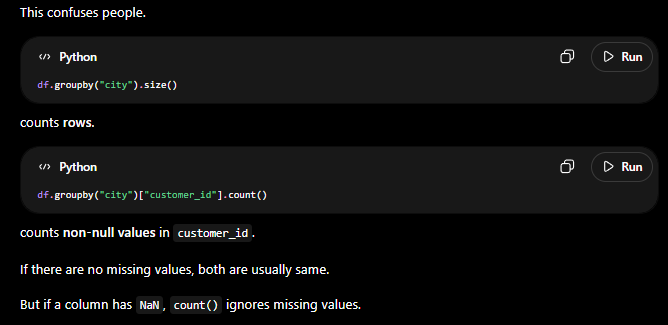

In [175]:
import pandas as pd
import numpy as np

data = {
    "customer_id": [
        101, 102, 103, 104, 105, 106, 107, 108, 109, 110,
        111, 112, 113, 114, 115, 116, 117, 118, 119, 120,
        121, 122, 123, 124, 125, 126, 127, 128, 129, 130
    ],
    "city": [
        "Rochester", "Buffalo", "Rochester", "Syracuse", "Albany",
        "Buffalo", "Rochester", "Albany", "Syracuse", "Buffalo",
        "Rochester", "Albany", "Syracuse", "Buffalo", "Rochester",
        "Albany", "Syracuse", "Rochester", "Buffalo", "Albany",
        "Rochester", "Syracuse", "Buffalo", "Albany", "Rochester",
        "Buffalo", "Syracuse", "Albany", "Rochester", "Buffalo"
    ],
    "product_category": [
        "Electronics", "Clothing", "Groceries", "Electronics", "Furniture",
        "Clothing", "Groceries", "Furniture", "Electronics", "Groceries",
        "Clothing", "Electronics", "Furniture", "Groceries", "Electronics",
        "Clothing", "Furniture", "Groceries", "Electronics", "Clothing",
        "Furniture", "Groceries", "Clothing", "Electronics", "Groceries",
        "Furniture", "Electronics", "Clothing", "Groceries", "Furniture"
    ],
    "order_amount": [
        249.99, 79.50, 34.20, 499.00, 899.99,
        120.75, 45.80, 650.00, 320.49, 28.99,
        95.00, 410.25, 720.00, 56.40, 199.99,
        88.75, 540.60, 63.25, 275.30, 110.00,
        805.90, 39.99, 70.25, 460.00, 52.10,
        680.45, 350.00, 99.99, 41.75, 755.20
    ],
    "is_returned": [
        False, False, True, False, True,
        False, False, False, True, False,
        False, True, False, False, False,
        True, False, False, True, False,
        False, True, False, False, False,
        True, False, False, True, False
    ]
}

df = pd.DataFrame(data)

In [176]:
# How many orders came from each city?
df.groupby('city')['customer_id'].count().reset_index(name='total_orders_from_each_city')

,city,total_orders_from_each_city
0,Albany,7
1,Buffalo,8
2,Rochester,9
3,Syracuse,6


In [177]:
# Average order amount by city
df.groupby('city')['order_amount'].mean().reset_index(name='avg_ord_amt')

,city,avg_ord_amt
0,Albany,388.425714
1,Buffalo,258.355000
2,Rochester,176.442222
3,Syracuse,411.680000


In [178]:
# For each city, number of returned orders
df[df['is_returned']==True].groupby('city')['is_returned'].count().reset_index(name='returned_order_per_city')

,city,returned_order_per_city
0,Albany,3
1,Buffalo,2
2,Rochester,2
3,Syracuse,2


In [179]:
# For each city, show total sales, average order amount, max order amount, and order count.

df.groupby("city").agg(
        total_revenue=("order_amount", "sum"),
        avg_order_amount=("order_amount", "mean"),
        max_order_amount=("order_amount", "max"),
        order_count=("customer_id", "count"),
        return_count=("is_returned", "sum"),
        return_rate=("is_returned", "mean")
    ).reset_index()

,city,total_revenue,avg_order_amount,max_order_amount,order_count,return_count,return_rate
0,Albany,2718.98,388.425714,899.99,7,3,0.428571
1,Buffalo,2066.84,258.355000,755.20,8,2,0.250000
2,Rochester,1587.98,176.442222,805.90,9,2,0.222222
3,Syracuse,2470.08,411.680000,720.00,6,2,0.333333


In [180]:
# transform: the trickiest but important one
# Normal groupby().agg() gives one row per group. But sometimes you want to keep the original rows and add group-level info.
# Add a new column showing average order amount of that customer’s city.

'''
Each row gets the average order amount for its own city.

Example:

Rochester row → Rochester average
Buffalo row → Buffalo average
Albany row → Albany average 
'''
df["city_avg_order_amount"] = df.groupby("city")["order_amount"].transform("mean")
df.head()

,customer_id,city,product_category,order_amount,is_returned,city_avg_order_amount
0,101,Rochester,Electronics,249.99,False,176.442222
1,102,Buffalo,Clothing,79.50,False,258.355000
2,103,Rochester,Groceries,34.20,True,176.442222
3,104,Syracuse,Electronics,499.00,False,411.680000
4,105,Albany,Furniture,899.99,True,388.425714


In [181]:
# Keep only cities whose average order amount is above 300. (if we wanna filter on grouped df)

df["city_avg"] = df.groupby("city")["order_amount"].transform("mean")
df[df["city_avg"] > 300]

# or

df.groupby("city").filter(lambda group: group["order_amount"].mean() > 300)

,customer_id,city,product_category,order_amount,is_returned,city_avg_order_amount,city_avg
3,104,Syracuse,Electronics,499.00,False,411.680000,411.680000
4,105,Albany,Furniture,899.99,True,388.425714,388.425714
7,108,Albany,Furniture,650.00,False,388.425714,388.425714
8,109,Syracuse,Electronics,320.49,True,411.680000,411.680000
11,112,Albany,Electronics,410.25,True,388.425714,388.425714
12,113,Syracuse,Furniture,720.00,False,411.680000,411.680000
15,116,Albany,Clothing,88.75,True,388.425714,388.425714
16,117,Syracuse,Furniture,540.60,False,411.680000,411.680000
19,120,Albany,Clothing,110.00,False,388.425714,388.425714
21,122,Syracuse,Groceries,39.99,True,411.680000,411.680000


The most important intuition:

```
groupby + agg = make summary table

groupby + transform = add group-level info back to every original row

groupby + filter = keep or remove full groups
```

In [182]:
df.head()

,customer_id,city,product_category,order_amount,is_returned,city_avg_order_amount,city_avg
0,101,Rochester,Electronics,249.99,False,176.442222,176.442222
1,102,Buffalo,Clothing,79.50,False,258.355000,258.355000
2,103,Rochester,Groceries,34.20,True,176.442222,176.442222
3,104,Syracuse,Electronics,499.00,False,411.680000,411.680000
4,105,Albany,Furniture,899.99,True,388.425714,388.425714


In [183]:
# Q1. Count the number of orders per city.
df.groupby('city')['customer_id'].count().reset_index(name='order_per_city')

# Q3. Find total revenue per product_category.
df.groupby('product_category')['order_amount'].sum().reset_index(name='total_revenue')

# Q4. Find the number of returned orders per city.
returned_orders=df[df['is_returned']==True]
returned_orders.groupby('city')['is_returned'].count().reset_index(name='returned_ord_per_city')

# Q5. Find the return rate per city.
df.groupby('city')['is_returned'].mean().reset_index(name='return_rate')

# Q6. Find the return rate per product_category.
df.groupby('product_category')['is_returned'].mean().reset_index(name='return_rate')

# Q7. For each city, calculate:
# total_revenue
# avg_order_amount
# max_order_amount
# order_count
df.groupby('city').agg(
    total_revenue=('order_amount','sum'),
    avg_order_amt=('order_amount','mean'),
    max_order_amt=('order_amount','max'),
    order_count=('customer_id','count')
).reset_index()

# Q9. Find the city with the highest total revenue.
df.groupby('city').agg(total_revenue=('order_amount','sum')).sort_values(by='total_revenue',ascending=False).iloc[[0]]

# Q10. Find the product_category with the highest average order_amount.
df.groupby('product_category').agg(avg_cost=('order_amount','mean')).sort_values(by='avg_cost',ascending=False).iloc[[0]].reset_index()

# Q11. Find revenue by city, but only for non-returned orders.
masked_df=df[df['is_returned']==False]
masked_df.groupby('city')['order_amount'].sum().reset_index()

# Q16. Group by city and product_category.
# For each combination, calculate total_revenue and order_count.
df.groupby(['city','product_category']).agg(
    total_revenue=('order_amount','sum'),
    order_count=('customer_id','count')
)

# Q18. Group by product_category and is_returned.
# Calculate average order_amount for each combination.
df.groupby(['product_category','is_returned'])[['order_amount']].mean()


# Q24. Add a new column city_avg_order_amount.
# Each row should contain the average order amount of that row's city.
df['city_avg_order_amount']=df.groupby('city')['order_amount'].transform('mean')
df.head()

# Q25. Create a new column above_city_avg. True if order_amount > city_avg_order_amount.
df['city_avg_order_amount']=df.groupby('city')['order_amount'].transform('mean')
df['above_city_avg']=df['order_amount']>df['city_avg_order_amount']
df.head()

# Q27. For each product_category, add a new column category_avg_order_amount.
# Each row should contain the average order amount of that row's product_category.
df['category_avg_order_amount']=df.groupby('product_category')['order_amount'].transform('mean')
df.head()

# Q30. Add a new column city_order_rank.
# Rank order_amount within each city from highest to lowest.
# Hint: groupby + rank.
# Q30. Rank order_amount within each city from highest to lowest

df["city_order_rank"] = df.groupby("city")["order_amount"].rank(ascending=False)

df[["customer_id", "city", "order_amount", "city_order_rank"]].sort_values(
    ["city", "city_order_rank"]
)

# Q31. Show the most expensive order from each city.
# Hint: use city_order_rank == 1.
df[df["city_order_rank"] == 1]

# Q32. Add a new column category_order_rank.
# Rank order_amount within each product_category from highest to lowest.
df['category_order_rank']=df.groupby('product_category')['order_amount'].rank(ascending=False)
df.head()

# Q33. Show top 2 orders from each product_category.
df[df["category_order_rank"] <= 2].sort_values(
    by=["product_category", "category_order_rank"]
)

# Q34. Keep only cities where average order_amount is greater than 300.
df1=df.groupby('city')['order_amount'].mean().reset_index()
df1[df1['order_amount']>300]

# Q37. For each city, calculate the percentage contribution of each order to that city's total revenue.
# Hint:
# city_total = groupby transform sum
# order_amount / city_total
df['avg_order_per_city']=df.groupby('city')['order_amount'].transform('sum')
df['perc_distribution in %']=(df['order_amount']/df['avg_order_per_city'])*100
df.head()

# Q41. Which city has the highest return_count?
mask=df[df['is_returned']==True].groupby('city')['customer_id'].count().reset_index(name='return_count')
mask.sort_values(by='return_count',ascending=False).iloc[[0]]

# Q51. Brain question:
# Find city-product combinations where total_revenue > 700.
# Return a summary table, not original rows.
mask=df.groupby(['city','product_category'])['order_amount'].sum().reset_index(name='total_revenue').query("total_revenue > 700")
mask

,city,product_category,total_revenue
1,Albany,Electronics,870.25
2,Albany,Furniture,1549.99
5,Buffalo,Furniture,1435.65
9,Rochester,Furniture,805.90
11,Syracuse,Electronics,1169.49
12,Syracuse,Furniture,1260.60


```
# 1. Summary table
df.groupby("col").agg(...).reset_index()

# 2. Filter first, then group
df[df["condition"]].groupby("col").agg(...)

# 3. Transform to keep original rows
df["new_col"] = df.groupby("col")["value"].transform("mean")

# 4. Rank within group
df["rank"] = df.groupby("col")["value"].rank(ascending=False)
```

CONCAT, MERGE AND JOIN



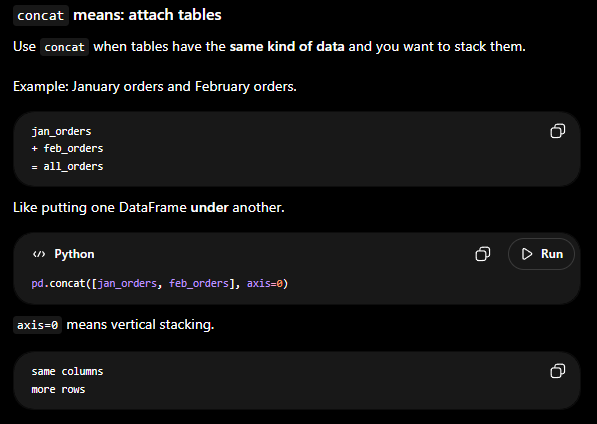

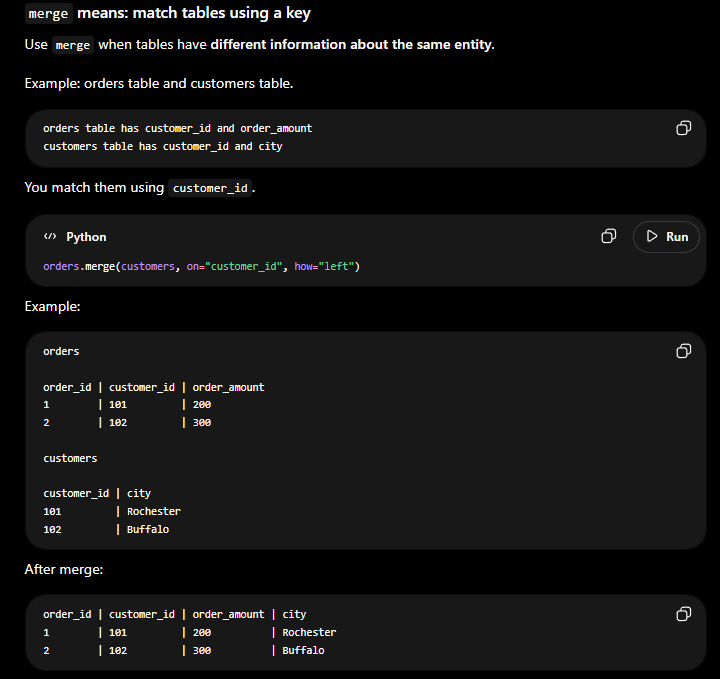

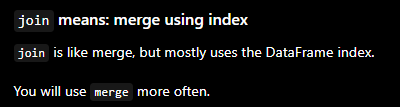

pd.merge() combines DataFrames based on specified columns (defaulting to an inner join), making it the versatile, SQL-like choice for joining on data keys.  In contrast, DataFrame.join() combines DataFrames based on their indexes (defaulting to a left join), serving as a convenience method for index-aligned data.


In [184]:
# creating data 

import pandas as pd
import numpy as np

customers = pd.DataFrame({
    "customer_id": [101, 102, 103, 104, 105, 106],
    "customer_name": ["Aman", "Priya", "Rohan", "Neha", "Karan", "Sara"],
    "city": ["Rochester", "Buffalo", "Albany", "Syracuse", "Rochester", "Buffalo"],
    "segment": ["Premium", "Regular", "Regular", "Premium", "Regular", "Premium"]
})

orders_jan = pd.DataFrame({
    "order_id": [1, 2, 3, 4],
    "customer_id": [101, 102, 103, 107],
    "product_id": ["P1", "P2", "P3", "P2"],
    "order_amount": [250, 120, 80, 500],
    "month": ["Jan", "Jan", "Jan", "Jan"]
})

orders_feb = pd.DataFrame({
    "order_id": [5, 6, 7],
    "customer_id": [101, 104, 106],
    "product_id": ["P2", "P4", "P1"],
    "order_amount": [300, 700, 150],
    "month": ["Feb", "Feb", "Feb"]
})

products = pd.DataFrame({
    "product_id": ["P1", "P2", "P3", "P4", "P5"],
    "product_name": ["Laptop", "Headphones", "Book", "Desk", "Mouse"],
    "category": ["Electronics", "Electronics", "Books", "Furniture", "Electronics"]
})

returns = pd.DataFrame({
    "order_id": [2, 6],
    "return_reason": ["Damaged", "Late delivery"]
})

In [185]:
customers

,customer_id,customer_name,city,segment
0,101,Aman,Rochester,Premium
1,102,Priya,Buffalo,Regular
2,103,Rohan,Albany,Regular
3,104,Neha,Syracuse,Premium
4,105,Karan,Rochester,Regular
5,106,Sara,Buffalo,Premium


In [186]:
orders_jan

,order_id,customer_id,product_id,order_amount,month
0,1,101,P1,250,Jan
1,2,102,P2,120,Jan
2,3,103,P3,80,Jan
3,4,107,P2,500,Jan


In [187]:
orders_feb

,order_id,customer_id,product_id,order_amount,month
0,5,101,P2,300,Feb
1,6,104,P4,700,Feb
2,7,106,P1,150,Feb


In [188]:
products

,product_id,product_name,category
0,P1,Laptop,Electronics
1,P2,Headphones,Electronics
2,P3,Book,Books
3,P4,Desk,Furniture
4,P5,Mouse,Electronics


In [189]:
returns

,order_id,return_reason
0,2,Damaged
1,6,Late delivery


In [190]:
# concat

orders = pd.concat([orders_jan, orders_feb])
orders

,order_id,customer_id,product_id,order_amount,month
0,1,101,P1,250,Jan
1,2,102,P2,120,Jan
2,3,103,P3,80,Jan
3,4,107,P2,500,Jan
0,5,101,P2,300,Feb
1,6,104,P4,700,Feb
2,7,106,P1,150,Feb


But notice the index may look weird:

0, 1, 2, 3, 0, 1, 2

In [191]:
orders = pd.concat([orders_jan, orders_feb], ignore_index=True)
orders

# ignore_index=True, means After stacking, create a fresh index.

,order_id,customer_id,product_id,order_amount,month
0,1,101,P1,250,Jan
1,2,102,P2,120,Jan
2,3,103,P3,80,Jan
3,4,107,P2,500,Jan
4,5,101,P2,300,Feb
5,6,104,P4,700,Feb
6,7,106,P1,150,Feb


vertical concatenation (stacking) axis=0is the default for concat, but you can also do horizontal concatenation (side by side) with axis=1.  This is like a join without any keys, just sticking them together based on their order.  So be careful with this one!

In [192]:
# merge 

# now we have orders table 
orders

,order_id,customer_id,product_id,order_amount,month
0,1,101,P1,250,Jan
1,2,102,P2,120,Jan
2,3,103,P3,80,Jan
3,4,107,P2,500,Jan
4,5,101,P2,300,Feb
5,6,104,P4,700,Feb
6,7,106,P1,150,Feb


In [193]:
customers

,customer_id,customer_name,city,segment
0,101,Aman,Rochester,Premium
1,102,Priya,Buffalo,Regular
2,103,Rohan,Albany,Regular
3,104,Neha,Syracuse,Premium
4,105,Karan,Rochester,Regular
5,106,Sara,Buffalo,Premium


In [194]:
orders.merge(customers, on='customer_id', how='inner')

,order_id,customer_id,product_id,order_amount,month,customer_name,city,segment
0,1,101,P1,250,Jan,Aman,Rochester,Premium
1,2,102,P2,120,Jan,Priya,Buffalo,Regular
2,3,103,P3,80,Jan,Rohan,Albany,Regular
3,5,101,P2,300,Feb,Aman,Rochester,Premium
4,6,104,P4,700,Feb,Neha,Syracuse,Premium
5,7,106,P1,150,Feb,Sara,Buffalo,Premium


In [195]:
orders.merge(customers, on='customer_id', how='left')

,order_id,customer_id,product_id,order_amount,month,customer_name,city,segment
0,1,101,P1,250,Jan,Aman,Rochester,Premium
1,2,102,P2,120,Jan,Priya,Buffalo,Regular
2,3,103,P3,80,Jan,Rohan,Albany,Regular
3,4,107,P2,500,Jan,NaN,NaN,NaN
4,5,101,P2,300,Feb,Aman,Rochester,Premium
5,6,104,P4,700,Feb,Neha,Syracuse,Premium
6,7,106,P1,150,Feb,Sara,Buffalo,Premium


In [196]:
# always check missing values.
#FAANG-style thinking: Never blindly merge. Always validate row counts and missing matches.

orders.merge(customers, on='customer_id', how='left')['customer_name'].isna().sum()

1

In [197]:
# analyze row count before and after merge.
# If row count increases unexpectedly, it means the right table has duplicate keys.

orders.shape, orders.merge(customers, on="customer_id", how="left").shape

((7, 5), (7, 8))

In [198]:
orders.merge(customers, on='customer_id', how='outer')

,order_id,customer_id,product_id,order_amount,month,customer_name,city,segment
0,1.0,101,P1,250.0,Jan,Aman,Rochester,Premium
1,5.0,101,P2,300.0,Feb,Aman,Rochester,Premium
2,2.0,102,P2,120.0,Jan,Priya,Buffalo,Regular
3,3.0,103,P3,80.0,Jan,Rohan,Albany,Regular
4,6.0,104,P4,700.0,Feb,Neha,Syracuse,Premium
5,NaN,105,NaN,NaN,NaN,Karan,Rochester,Regular
6,7.0,106,P1,150.0,Feb,Sara,Buffalo,Premium
7,4.0,107,P2,500.0,Jan,NaN,NaN,NaN


In [199]:
# Another excellent trick.

orders.merge(customers, on="customer_id", how="outer", indicator=True)

,order_id,customer_id,product_id,order_amount,month,customer_name,city,segment,_merge
0,1.0,101,P1,250.0,Jan,Aman,Rochester,Premium,both
1,5.0,101,P2,300.0,Feb,Aman,Rochester,Premium,both
2,2.0,102,P2,120.0,Jan,Priya,Buffalo,Regular,both
3,3.0,103,P3,80.0,Jan,Rohan,Albany,Regular,both
4,6.0,104,P4,700.0,Feb,Neha,Syracuse,Premium,both
5,NaN,105,NaN,NaN,NaN,Karan,Rochester,Regular,right_only
6,7.0,106,P1,150.0,Feb,Sara,Buffalo,Premium,both
7,4.0,107,P2,500.0,Jan,NaN,NaN,NaN,left_only


In analytics, default thinking:

main_table.merge(lookup_table, on="key", how="left")

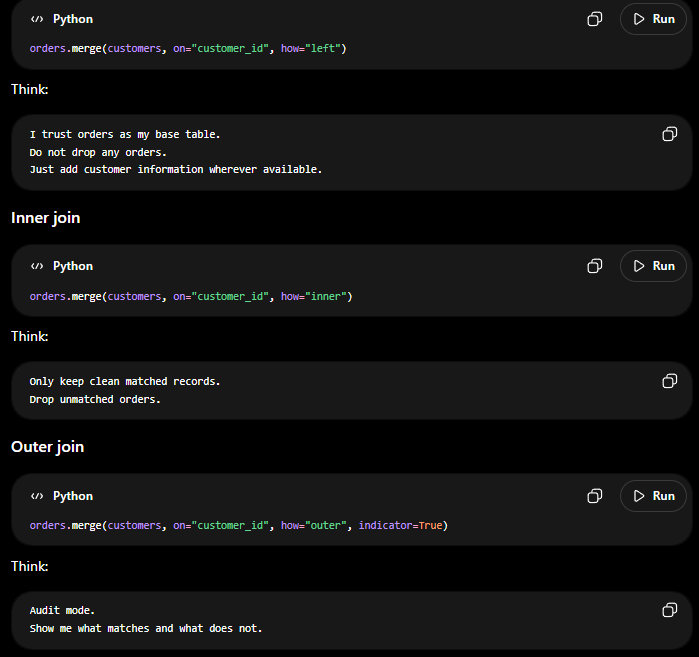

In [200]:
# Chaining multiple merges

orders_full = (
    orders
    .merge(customers, on="customer_id", how="left")
    .merge(products, on="product_id", how="left")
)

orders_full

,order_id,customer_id,product_id,order_amount,month,customer_name,city,segment,product_name,category
0,1,101,P1,250,Jan,Aman,Rochester,Premium,Laptop,Electronics
1,2,102,P2,120,Jan,Priya,Buffalo,Regular,Headphones,Electronics
2,3,103,P3,80,Jan,Rohan,Albany,Regular,Book,Books
3,4,107,P2,500,Jan,NaN,NaN,NaN,Headphones,Electronics
4,5,101,P2,300,Feb,Aman,Rochester,Premium,Headphones,Electronics
5,6,104,P4,700,Feb,Neha,Syracuse,Premium,Desk,Furniture
6,7,106,P1,150,Feb,Sara,Buffalo,Premium,Laptop,Electronics


In [201]:
returns

,order_id,return_reason
0,2,Damaged
1,6,Late delivery


In [202]:
orders_full = orders_full.merge(returns, on="order_id", how="left")
orders_full

,order_id,customer_id,product_id,order_amount,month,customer_name,city,segment,product_name,category,return_reason
0,1,101,P1,250,Jan,Aman,Rochester,Premium,Laptop,Electronics,NaN
1,2,102,P2,120,Jan,Priya,Buffalo,Regular,Headphones,Electronics,Damaged
2,3,103,P3,80,Jan,Rohan,Albany,Regular,Book,Books,NaN
3,4,107,P2,500,Jan,NaN,NaN,NaN,Headphones,Electronics,NaN
4,5,101,P2,300,Feb,Aman,Rochester,Premium,Headphones,Electronics,NaN
5,6,104,P4,700,Feb,Neha,Syracuse,Premium,Desk,Furniture,Late delivery
6,7,106,P1,150,Feb,Sara,Buffalo,Premium,Laptop,Electronics,NaN


In [203]:
orders_full["is_returned"] = orders_full["return_reason"].notna()
orders_full

,order_id,customer_id,product_id,order_amount,month,customer_name,city,segment,product_name,category,return_reason,is_returned
0,1,101,P1,250,Jan,Aman,Rochester,Premium,Laptop,Electronics,NaN,False
1,2,102,P2,120,Jan,Priya,Buffalo,Regular,Headphones,Electronics,Damaged,True
2,3,103,P3,80,Jan,Rohan,Albany,Regular,Book,Books,NaN,False
3,4,107,P2,500,Jan,NaN,NaN,NaN,Headphones,Electronics,NaN,False
4,5,101,P2,300,Feb,Aman,Rochester,Premium,Headphones,Electronics,NaN,False
5,6,104,P4,700,Feb,Neha,Syracuse,Premium,Desk,Furniture,Late delivery,True
6,7,106,P1,150,Feb,Sara,Buffalo,Premium,Laptop,Electronics,NaN,False


Which table’s rows am I not allowed to lose? is what determines the type of join.

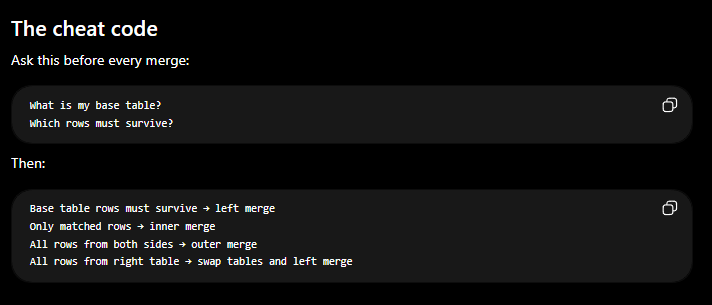

practicing merges and joins

In [204]:
import pandas as pd
import numpy as np

# ============================================================
# DATASET: FAANG-style e-commerce / product analytics data
# ============================================================

users = pd.DataFrame({
    "user_id": [101, 102, 103, 104, 105, 106, 107, 108, 109, 110],
    "user_name": ["Aman", "Priya", "Rohan", "Neha", "Karan", "Sara", "Vikram", "Isha", "Kabir", "Meera"],
    "signup_date": pd.to_datetime([
        "2024-01-05", "2024-01-10", "2024-02-01", "2024-02-15", "2024-03-01",
        "2024-03-10", "2024-04-01", "2024-04-15", "2024-05-01", "2024-05-20"
    ]),
    "country": ["US", "US", "Canada", "US", "India", "Canada", "US", "India", "US", "Canada"],
    "acquisition_channel": ["Ads", "Organic", "Referral", "Ads", "Organic", "Referral", "Ads", "Organic", "Referral", "Ads"]
})

orders = pd.DataFrame({
    "order_id": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
    "user_id": [101, 102, 103, 101, 104, 111, 105, 106, 102, 109, 110, 112],
    "product_id": ["P1", "P2", "P3", "P2", "P4", "P1", "P5", "P3", "P6", "P2", "P7", "P4"],
    "order_amount": [120, 80, 200, 150, 700, 90, 40, 300, 500, 110, 250, 650],
    "order_date": pd.to_datetime([
        "2024-06-01", "2024-06-02", "2024-06-02", "2024-06-03",
        "2024-06-04", "2024-06-04", "2024-06-05", "2024-06-06",
        "2024-06-07", "2024-06-08", "2024-06-09", "2024-06-10"
    ])
})

products = pd.DataFrame({
    "product_id": ["P1", "P2", "P3", "P4", "P5", "P6"],
    "product_name": ["Keyboard", "Mouse", "Monitor", "Desk", "Notebook", "Headphones"],
    "category": ["Electronics", "Electronics", "Electronics", "Furniture", "Stationery", "Electronics"],
    "cost": [50, 30, 120, 400, 10, 220]
})

payments = pd.DataFrame({
    "payment_id": [1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010],
    "order_id": [1, 2, 3, 4, 5, 7, 8, 9, 10, 13],
    "payment_method": ["Card", "UPI", "Card", "PayPal", "Card", "UPI", "Card", "Card", "PayPal", "Card"],
    "payment_status": ["Success", "Success", "Failed", "Success", "Success", "Success", "Success", "Failed", "Success", "Success"]
})

returns = pd.DataFrame({
    "return_id": [201, 202, 203],
    "order_id": [2, 5, 9],
    "return_reason": ["Damaged", "Wrong item", "Late delivery"],
    "return_date": pd.to_datetime(["2024-06-05", "2024-06-08", "2024-06-12"])
})

support_tickets = pd.DataFrame({
    "ticket_id": [301, 302, 303, 304, 305, 306],
    "user_id": [101, 102, 102, 105, 108, 112],
    "issue_type": ["Delivery", "Payment", "Return", "Product", "Account", "Delivery"],
    "created_at": pd.to_datetime([
        "2024-06-02", "2024-06-03", "2024-06-06",
        "2024-06-07", "2024-06-08", "2024-06-11"
    ])
})

print("users")
display(users)

print("orders")
display(orders)

print("products")
display(products)

print("payments")
display(payments)

print("returns")
display(returns)

print("support_tickets")
display(support_tickets)

users


,user_id,user_name,signup_date,country,acquisition_channel
0,101,Aman,2024-01-05,US,Ads
1,102,Priya,2024-01-10,US,Organic
2,103,Rohan,2024-02-01,Canada,Referral
3,104,Neha,2024-02-15,US,Ads
4,105,Karan,2024-03-01,India,Organic
5,106,Sara,2024-03-10,Canada,Referral
6,107,Vikram,2024-04-01,US,Ads
7,108,Isha,2024-04-15,India,Organic
8,109,Kabir,2024-05-01,US,Referral
9,110,Meera,2024-05-20,Canada,Ads


orders


,order_id,user_id,product_id,order_amount,order_date
0,1,101,P1,120,2024-06-01
1,2,102,P2,80,2024-06-02
2,3,103,P3,200,2024-06-02
3,4,101,P2,150,2024-06-03
4,5,104,P4,700,2024-06-04
5,6,111,P1,90,2024-06-04
6,7,105,P5,40,2024-06-05
7,8,106,P3,300,2024-06-06
8,9,102,P6,500,2024-06-07
9,10,109,P2,110,2024-06-08


products


...

,payment_id,order_id,payment_method,payment_status
0,1001,1,Card,Success
1,1002,2,UPI,Success
2,1003,3,Card,Failed
3,1004,4,PayPal,Success
4,1005,5,Card,Success
5,1006,7,UPI,Success
6,1007,8,Card,Success
7,1008,9,Card,Failed
8,1009,10,PayPal,Success
9,1010,13,Card,Success


returns


,return_id,order_id,return_reason,return_date
0,201,2,Damaged,2024-06-05
1,202,5,Wrong item,2024-06-08
2,203,9,Late delivery,2024-06-12


support_tickets


,ticket_id,user_id,issue_type,created_at
0,301,101,Delivery,2024-06-02
1,302,102,Payment,2024-06-03
2,303,102,Return,2024-06-06
3,304,105,Product,2024-06-07
4,305,108,Account,2024-06-08
5,306,112,Delivery,2024-06-11


In [205]:
orders.columns

Index(['order_id', 'user_id', 'product_id', 'order_amount', 'order_date'], dtype='object')

In [206]:
# Q1. Add user_name, country, and acquisition_channel to every order.
orders.merge(users, on='user_id', how='left')[['user_id','order_id','user_name','country','acquisition_channel', 'order_amount', 'order_date']]

# Q2. Add product_name and category to every order.
orders.merge(products, on='product_id', how='left').loc[:, 'order_id':'category']

# Q5. Show all users and their orders, including users who never ordered.
df1 = users.merge(orders, on='user_id', how='left')
df1[df1['order_id'].isna()][['user_name']]

# Q8. Find products that were never ordered.
merged = products.merge(orders, on='product_id', how='left')
never_ordered = merged[merged['order_id'].isna()]
never_ordered

# Q10. Find orders that were returned.
grp = orders.merge(returns, on='order_id', how='left')
grp[grp['return_id'].isna()]

# Q11. Add a boolean column is_returned to every order.
grp = orders.merge(returns, on='order_id', how='left')
grp['is_returned'] = (~grp['return_id'].isna())
grp

# Q12. Find successful paid orders only.
full_orders = orders.merge(payments, on='order_id', how='left')
full_orders[full_orders['payment_status']=='Success']

# Q13. Find orders that do not have any payment record.
full_orders = orders.merge(payments, on='order_id', how='left')
full_orders[full_orders['payment_status'].isna()]

# Q16. Find users who contacted support but never placed an order.
users_and_support = users.merge(support_tickets, on='user_id', how='left')
users_contacted_support = users_and_support[~users_and_support['ticket_id'].isna()]
order_info_of_users_contacted_support = users_contacted_support.merge(orders, on='user_id', how='left')
order_info_of_users_contacted_support[order_info_of_users_contacted_support['order_id'].isna()]

,user_id,user_name,signup_date,country,acquisition_channel,ticket_id,issue_type,created_at,order_id,product_id,order_amount,order_date
7,108,Isha,2024-04-15,India,Organic,305.0,Account,2024-06-08,NaN,NaN,NaN,NaT


In [207]:
# Write a query to identify the manager with the biggest team size. You may assume there is only one manager with the largest team size.

import pandas as pd

employees = pd.DataFrame({
    'id': [1, 2, 3, 4, 5, 6, 7, 8, 9],
    'name': ['Alice', 'Bob', 'Charlie', 'David', 'Eva', 'Frank', 'Grace', 'Helen', 'Ian'],
    'manager_id': [101, 101, 102, 101, 103, 102, 101, 103, 103]
})

managers = pd.DataFrame({
    'id': [101, 102, 103],
    'name': ['Michael', 'Sarah', 'Priya'],
    'team': ['Sales', 'Engineering', 'Support']
})

df = employees.merge(managers, left_on='manager_id', right_on='id', how='left')
result = (
    df.groupby('name_y')['name_x']
    .count()
    .reset_index()
    .sort_values(by='name_x', ascending=False)
    .iloc[[0]]
    .rename(columns={
        'name_y': 'manager',
        'name_x': 'team_size'
    })[['manager', 'team_size']]
)

result

,manager,team_size
0,Michael,4


WINDOW functions

Window functions are very important for FAANG-style analytics because they answer questions where each row needs context from nearby rows or from its group, without collapsing the data like groupby().agg() does.

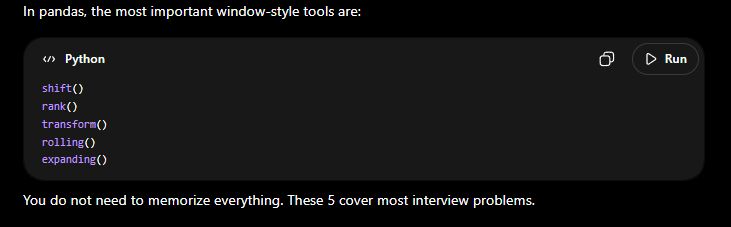

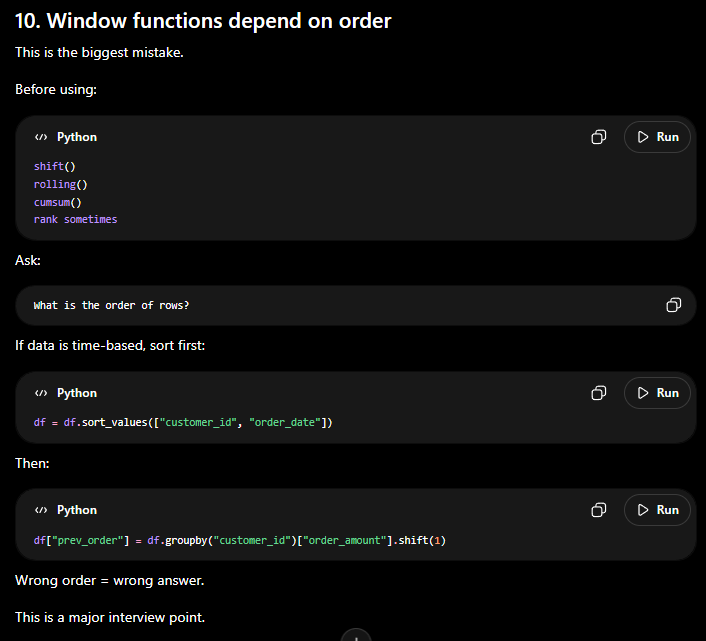

In [208]:
import pandas as pd
import numpy as np

# -----------------------------
# Window Functions Practice Data
# -----------------------------

data = {
    "user_id": [
        "U1","U2","U1","U3","U2","U1","U4","U3","U5","U2",
        "U1","U4","U5","U3","U2","U1","U5","U4","U3","U2",
        "U1","U5","U4","U3","U2","U1","U5","U4","U3","U2"
    ],
    "order_date": [
        "2024-01-01","2024-01-01","2024-01-03","2024-01-04","2024-01-05",
        "2024-01-07","2024-01-08","2024-01-09","2024-01-10","2024-01-11",
        "2024-01-13","2024-01-14","2024-01-15","2024-01-16","2024-01-18",
        "2024-01-20","2024-01-21","2024-01-22","2024-01-23","2024-01-25",
        "2024-01-27","2024-01-28","2024-01-29","2024-01-30","2024-02-01",
        "2024-02-03","2024-02-04","2024-02-05","2024-02-07","2024-02-08"
    ],
    "city": [
        "Rochester","Buffalo","Rochester","Albany","Buffalo",
        "Rochester","Syracuse","Albany","Rochester","Buffalo",
        "Rochester","Syracuse","Rochester","Albany","Buffalo",
        "Rochester","Rochester","Syracuse","Albany","Buffalo",
        "Rochester","Rochester","Syracuse","Albany","Buffalo",
        "Rochester","Rochester","Syracuse","Albany","Buffalo"
    ],
    "category": [
        "Electronics","Groceries","Clothing","Furniture","Electronics",
        "Groceries","Clothing","Electronics","Furniture","Groceries",
        "Electronics","Furniture","Groceries","Clothing","Furniture",
        "Electronics","Clothing","Groceries","Furniture","Electronics",
        "Furniture","Electronics","Clothing","Groceries","Furniture",
        "Groceries","Furniture","Electronics","Clothing","Groceries"
    ],
    "order_amount": [
        220, 35, 75, 640, 310,
        55, 95, 420, 710, 45,
        500, 860, 60, 120, 690,
        250, 80, 40, 730, 330,
        910, 450, 110, 65, 720,
        95, 800, 390, 150, 50
    ],
    "session_minutes": [
        12, 5, 8, 20, 15,
        6, 9, 18, 25, 4,
        16, 30, 7, 10, 22,
        13, 9, 5, 28, 17,
        35, 19, 11, 6, 24,
        8, 29, 16, 12, 5
    ],
    "is_returned": [
        False, False, True, False, False,
        False, True, False, True, False,
        False, False, False, True, False,
        False, True, False, False, False,
        False, False, True, False, True,
        False, False, False, True, False
    ]
}

df = pd.DataFrame(data)
df["order_date"] = pd.to_datetime(df["order_date"])

df.head()

,user_id,order_date,city,category,order_amount,session_minutes,is_returned
0,U1,2024-01-01,Rochester,Electronics,220,12,False
1,U2,2024-01-01,Buffalo,Groceries,35,5,False
2,U1,2024-01-03,Rochester,Clothing,75,8,True
3,U3,2024-01-04,Albany,Furniture,640,20,False
4,U2,2024-01-05,Buffalo,Electronics,310,15,False


In [209]:
# IMPORTANT:
# For window functions involving previous/next/cumulative/rolling,
# always think about sorting first.
df = df.sort_values(["user_id", "order_date"]).reset_index(drop=True)
df.head()

,user_id,order_date,city,category,order_amount,session_minutes,is_returned
0,U1,2024-01-01,Rochester,Electronics,220,12,False
1,U1,2024-01-03,Rochester,Clothing,75,8,True
2,U1,2024-01-07,Rochester,Groceries,55,6,False
3,U1,2024-01-13,Rochester,Electronics,500,16,False
4,U1,2024-01-20,Rochester,Electronics,250,13,False


In [210]:
# Q1. For each user, create a column called previous_order_amount.
# It should show that user's previous order_amount.
# First order for each user should be NaN.
df["previous_order_amount"] = df.groupby("user_id")["order_amount"].shift(1)
df.head()

# # Q2. For each user, create a column called order_amount_change.
# # It should be current order_amount - previous_order_amount.
df['order_amount_change'] = df['order_amount'] - df['previous_order_amount']
df.head()

# # Q3. For each user, create a column called previous_order_date.
# # Then create days_since_previous_order.
df['previous_order_date'] = df.groupby('user_id')['order_date'].shift(1)
df["days_since_previous_order"] = (
    df["order_date"] - df["previous_order_date"]
).dt.days

df.head()

# # Q4. For each user, create a column called user_running_spend.
# # It should show cumulative spend up to that order.
df['user_running_spend'] = df.groupby("user_id")['order_amount'].cumsum()
df.head()

# Q5. For each user, create a column called purchase_number.
# It should show 1 for first purchase, 2 for second purchase, etc.
df["purchase_number"] = df.groupby("user_id").cumcount() + 1
df.head()

# Q6. Rank each user's orders by order_amount from highest to lowest.
# Create a column user_order_rank.
df['user_order_rank'] = df.groupby("user_id")['order_amount'].rank(method='dense',ascending=False)
df.head()

# Q7. Show the highest-value order for each user.
df[df['user_order_rank']==1]

# Q8. For each city, create city_avg_order_amount using transform.
# Then create above_city_avg = True if order_amount > city_avg_order_amount.
df['city_avg_order_amount'] = df.groupby('city')['order_amount'].transform('mean')
df['city_above_avg'] = df['order_amount']>df['city_avg_order_amount']
df.head()

# Q9. For each category, create category_total_revenue.
df.groupby('category')['order_amount'].sum().reset_index()

# Q10. For each city, rank orders by session_minutes from longest to shortest.
# Show the top 2 longest sessions from each city.
df["city_session_rank"] = df.groupby("city")["session_minutes"].rank(ascending=False)
df[df["city_session_rank"] <= 2].sort_values(["city", "city_session_rank"]).head()

,user_id,order_date,city,category,order_amount,session_minutes,is_returned,previous_order_amount,order_amount_change,previous_order_date,days_since_previous_order,user_running_spend,purchase_number,user_order_rank,city_avg_order_amount,city_above_avg,city_session_rank
17,U3,2024-01-23,Albany,Furniture,730,28,False,120.0,610.0,2024-01-16,7.0,1910,4,1.0,354.166667,True,1.0
14,U3,2024-01-04,Albany,Furniture,640,20,False,NaN,NaN,NaT,NaN,640,1,2.0,354.166667,True,2.0
12,U2,2024-02-01,Buffalo,Furniture,720,24,True,330.0,390.0,2024-01-25,7.0,2130,6,1.0,311.428571,True,1.0
10,U2,2024-01-18,Buffalo,Furniture,690,22,False,45.0,645.0,2024-01-11,7.0,1080,4,2.0,311.428571,True,2.0
5,U1,2024-01-27,Rochester,Furniture,910,35,False,250.0,660.0,2024-01-20,7.0,2010,6,1.0,350.416667,True,1.0


More practice with window functions

In [211]:
import pandas as pd
import numpy as np

# ---------------------------------------------------
# Window Function Practice Dataset for Pandas
# Inspired by SQL window function interview patterns
# ---------------------------------------------------

data = {
    "order_id": [
        1001, 1002, 1003, 1004, 1005,
        1006, 1007, 1008, 1009, 1010,
        1011, 1012, 1013, 1014, 1015,
        1016, 1017, 1018, 1019, 1020,
        1021, 1022, 1023, 1024, 1025,
        1026, 1027, 1028, 1029, 1030
    ],
    "customer_id": [
        "C1", "C2", "C1", "C3", "C2",
        "C1", "C4", "C3", "C2", "C5",
        "C1", "C4", "C5", "C3", "C2",
        "C1", "C5", "C4", "C3", "C2",
        "C1", "C5", "C4", "C3", "C2",
        "C1", "C5", "C4", "C3", "C2"
    ],
    "order_date": [
        "2024-01-01", "2024-01-02", "2024-01-04", "2024-01-05", "2024-01-07",
        "2024-01-08", "2024-01-09", "2024-01-10", "2024-01-12", "2024-01-13",
        "2024-01-15", "2024-01-16", "2024-01-17", "2024-01-18", "2024-01-20",
        "2024-01-21", "2024-01-22", "2024-01-24", "2024-01-25", "2024-01-26",
        "2024-01-28", "2024-01-29", "2024-01-30", "2024-02-01", "2024-02-02",
        "2024-02-03", "2024-02-04", "2024-02-05", "2024-02-06", "2024-02-07"
    ],
    "city": [
        "Rochester", "Buffalo", "Rochester", "Albany", "Buffalo",
        "Rochester", "Syracuse", "Albany", "Buffalo", "Rochester",
        "Rochester", "Syracuse", "Rochester", "Albany", "Buffalo",
        "Rochester", "Rochester", "Syracuse", "Albany", "Buffalo",
        "Rochester", "Rochester", "Syracuse", "Albany", "Buffalo",
        "Rochester", "Rochester", "Syracuse", "Albany", "Buffalo"
    ],
    "category": [
        "Electronics", "Clothing", "Groceries", "Furniture", "Electronics",
        "Electronics", "Groceries", "Furniture", "Clothing", "Electronics",
        "Groceries", "Furniture", "Clothing", "Electronics", "Groceries",
        "Furniture", "Electronics", "Clothing", "Groceries", "Furniture",
        "Electronics", "Groceries", "Furniture", "Clothing", "Electronics",
        "Groceries", "Furniture", "Electronics", "Clothing", "Groceries"
    ],
    "order_amount": [
        250, 80, 40, 700, 320,
        500, 60, 850, 120, 400,
        75, 600, 95, 300, 55,
        900, 450, 130, 65, 760,
        520, 35, 680, 110, 340,
        85, 720, 390, 105, 45
    ],
    "is_returned": [
        False, False, True, False, True,
        False, False, False, False, False,
        False, True, False, True, False,
        False, False, False, True, False,
        False, False, True, False, False,
        True, False, False, False, False
    ]
}

df = pd.DataFrame(data)
df["order_date"] = pd.to_datetime(df["order_date"])
df.head()

,order_id,customer_id,order_date,city,category,order_amount,is_returned
0,1001,C1,2024-01-01,Rochester,Electronics,250,False
1,1002,C2,2024-01-02,Buffalo,Clothing,80,False
2,1003,C1,2024-01-04,Rochester,Groceries,40,True
3,1004,C3,2024-01-05,Albany,Furniture,700,False
4,1005,C2,2024-01-07,Buffalo,Electronics,320,True


In [212]:
# For each customer, add a column customer_total_spend.
df['customer_total_spend'] = df.groupby('customer_id')['order_amount'].transform('sum')
df.head()

# Q2. For each city, add a column city_avg_order_amount.
df['city_avg_order_amount'] = df.groupby('city')['order_amount'].transform('mean')
df.head()

# Q3. Create a column above_city_avg.
df['above_city_avg'] = df['order_amount'] > df['city_avg_order_amount']
df.head()

# Q4. For each category, calculate category_total_revenue on every row.
# Then create category_revenue_pct showing each order's percentage contribution to its category revenue.
df['category_total_revenue'] = df.groupby('category')['order_amount'].transform('sum')
df['category_revenue_pct'] = (df['order_amount'] / df['category_total_revenue'])*100
df.head()

# Q5. Rank orders within each city by order_amount from highest to lowest.
df['order_rank'] = df.groupby('city')['order_amount'].rank(method='dense', ascending=False)
df.head()

# Show the top 2 most expensive orders from each city.
df[df['order_rank']<=2].sort_values(by=['city','order_rank'])

,order_id,customer_id,order_date,city,category,order_amount,is_returned,customer_total_spend,city_avg_order_amount,above_city_avg,category_total_revenue,category_revenue_pct,order_rank
7,1008,C3,2024-01-10,Albany,Furniture,850,False,2130,355.000000,True,5210,16.314779,1.0
3,1004,C3,2024-01-05,Albany,Furniture,700,False,2130,355.000000,True,5210,13.435701,2.0
19,1020,C2,2024-01-26,Buffalo,Furniture,760,False,1720,245.714286,True,5210,14.587332,1.0
24,1025,C2,2024-02-02,Buffalo,Electronics,340,False,1720,245.714286,True,3470,9.798271,2.0
15,1016,C1,2024-01-21,Rochester,Furniture,900,False,2370,339.166667,True,5210,17.274472,1.0
26,1027,C5,2024-02-04,Rochester,Furniture,720,False,1700,339.166667,True,5210,13.819578,2.0
22,1023,C4,2024-01-30,Syracuse,Furniture,680,True,1860,372.000000,True,5210,13.051823,1.0
11,1012,C4,2024-01-16,Syracuse,Furniture,600,True,1860,372.000000,True,5210,11.516315,2.0


Pivot in pandas

```
pd.pivot_table(
    data=df,
    index="rows",
    columns="new columns",
    values="numbers to calculate",
    aggfunc="calculation"
)
```

For each index group,
split results across columns,
calculate aggfunc on values.

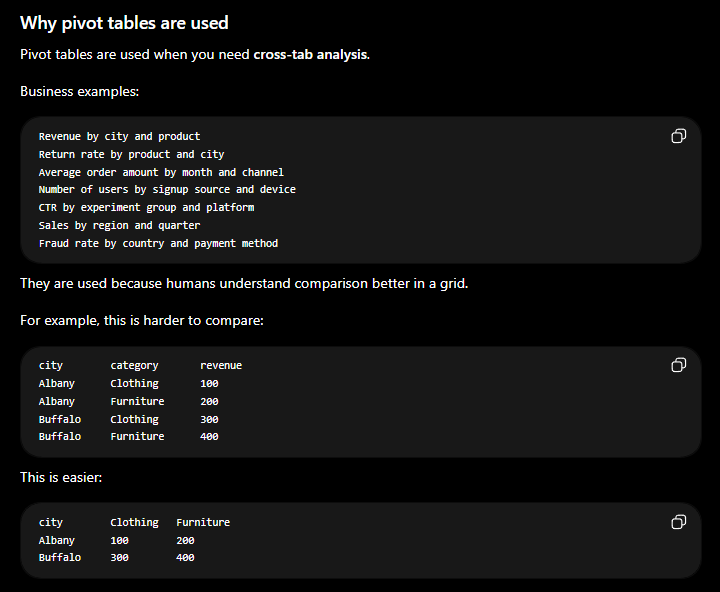

Pivot table is basically groupby + unstack

In [213]:
df.groupby(["city", "category"])["order_amount"].sum().unstack()

category,Clothing,Electronics,Furniture,Groceries
city,,,,
Albany,215,300,1550,65
Buffalo,200,660,760,100
Rochester,95,2120,1620,235
Syracuse,130,390,1280,60


In [216]:
pd.pivot_table(
    data=df,
    index="city",
    columns="category",
    values="order_amount",
    aggfunc=["sum", "mean"],
    fill_value=0
)

sum                                     mean              \
category  Clothing Electronics Furniture Groceries Clothing Electronics   
city                                                                      
Albany         215         300      1550        65    107.5       300.0   
Buffalo        200         660       760       100    100.0       330.0   
Rochester       95        2120      1620       235     95.0       424.0   
Syracuse       130         390      1280        60    130.0       390.0   

                               
category  Furniture Groceries  
city                           
Albany        775.0     65.00  
Buffalo       760.0     50.00  
Rochester     810.0     58.75  
Syracuse      640.0     60.00

Flattening pivot table columns

When pivot tables create multi-level columns, flatten them.

In [217]:
pivot = pd.pivot_table(
    data=df,
    index="city",
    columns="category",
    values=["order_amount", "is_returned"],
    aggfunc={
        "order_amount": "sum",
        "is_returned": "mean"
    },
    fill_value=0
)

pivot.columns = [
    f"{value}_{category}" for value, category in pivot.columns
]

pivot = pivot.reset_index()

pivot

,city,is_returned_Clothing,is_returned_Electronics,is_returned_Furniture,is_returned_Groceries,order_amount_Clothing,order_amount_Electronics,order_amount_Furniture,order_amount_Groceries
0,Albany,0.0,1.0,0.0,1.0,215,300,1550,65
1,Buffalo,0.0,0.5,0.0,0.0,200,660,760,100
2,Rochester,0.0,0.0,0.0,0.5,95,2120,1620,235
3,Syracuse,0.0,0.0,1.0,0.0,130,390,1280,60


```
index = main thing you want rows for
columns = comparison dimension
values = number you are calculating
aggfunc = calculation
df_pivot.columns = [f"{col[0]}_{col[1]}" for col in df_pivot.columns]
```

In [219]:
import pandas as pd
import numpy as np

data = {
    "customer_id": [
        101, 102, 103, 104, 105, 106, 107, 108, 109, 110,
        111, 112, 113, 114, 115, 116, 117, 118, 119, 120,
        121, 122, 123, 124, 125, 126, 127, 128, 129, 130
    ],
    "city": [
        "Rochester", "Buffalo", "Rochester", "Syracuse", "Albany",
        "Buffalo", "Rochester", "Albany", "Syracuse", "Buffalo",
        "Rochester", "Albany", "Syracuse", "Buffalo", "Rochester",
        "Albany", "Syracuse", "Rochester", "Buffalo", "Albany",
        "Rochester", "Syracuse", "Buffalo", "Albany", "Rochester",
        "Buffalo", "Syracuse", "Albany", "Rochester", "Buffalo"
    ],
    "product_category": [
        "Electronics", "Clothing", "Groceries", "Electronics", "Furniture",
        "Clothing", "Groceries", "Furniture", "Electronics", "Groceries",
        "Clothing", "Electronics", "Furniture", "Groceries", "Electronics",
        "Clothing", "Furniture", "Groceries", "Electronics", "Clothing",
        "Furniture", "Groceries", "Clothing", "Electronics", "Groceries",
        "Furniture", "Electronics", "Clothing", "Groceries", "Furniture"
    ],
    "order_amount": [
        249.99, 79.50, 34.20, 499.00, 899.99,
        120.75, 45.80, 650.00, 320.49, 28.99,
        95.00, 410.25, 720.00, 56.40, 199.99,
        88.75, 540.60, 63.25, 275.30, 110.00,
        805.90, 39.99, 70.25, 460.00, 52.10,
        680.45, 350.00, 99.99, 41.75, 755.20
    ],
    "is_returned": [
        False, False, True, False, True,
        False, False, False, True, False,
        False, True, False, False, False,
        True, False, False, True, False,
        False, True, False, False, False,
        True, False, False, True, False
    ]
}

df = pd.DataFrame(data)

df["high_value"] = df["order_amount"] > 500
df["discount_eligible"] = (df["order_amount"] > 300) & (~df["is_returned"])

df.head()

,customer_id,city,product_category,order_amount,is_returned,high_value,discount_eligible
0,101,Rochester,Electronics,249.99,False,False,False
1,102,Buffalo,Clothing,79.50,False,False,False
2,103,Rochester,Groceries,34.20,True,False,False
3,104,Syracuse,Electronics,499.00,False,False,True
4,105,Albany,Furniture,899.99,True,True,False


In [233]:
# Q1. Create a pivot table showing total revenue by city across product_category.
# Rows: city
# Columns: product_category
# Values: order_amount
# Aggregation: sum
# Replace missing values with 0.

df.groupby(['city','product_category'])['order_amount'].sum().unstack()
# or
pd.pivot_table(df, index='city', columns='product_category', values='order_amount', aggfunc='sum', fill_value=0)

# Q3. Create a pivot table showing number of orders by city across product_category.
pd.pivot_table(df, index='city', columns='product_category', values='order_amount', aggfunc='count', fill_value=0)

# Q4. Create a pivot table showing return rate by city across product_category.
pd.pivot_table(df, index='city', columns='product_category', values='is_returned', aggfunc='mean', fill_value=0)

# Q5. Create a total revenue pivot table by city and product_category.
# Add row and column totals using margins=True.
pd.pivot_table(df, index='city', columns='product_category', values='order_amount', aggfunc='sum', fill_value=0, margins=True)

# Q6. Create a pivot table with multiple row indexes:
# Rows: city and is_returned
# Columns: product_category
# Values: order_amount
# Aggregation: sum
# Replace missing values with 0.
pd.pivot_table(df, index=['city','is_returned'], columns='product_category', values='order_amount', aggfunc=['sum','mean'], fill_value=0)

# Q10. Create a crosstab showing count of orders by city and product_category.
# This should be like a count pivot table.
pd.pivot_table(df, index=['city'], columns='product_category', values='customer_id', aggfunc='count', fill_value=0, margins=True)

product_category,Clothing,Electronics,Furniture,Groceries,All
city,,,,,
Albany,3,2,2,0,7
Buffalo,3,1,2,2,8
Rochester,1,2,1,5,9
Syracuse,0,3,2,1,6
All,7,8,7,8,30


binning + bucketing in pandas

There are two important functions:

- pd.cut()
- pd.qcut()

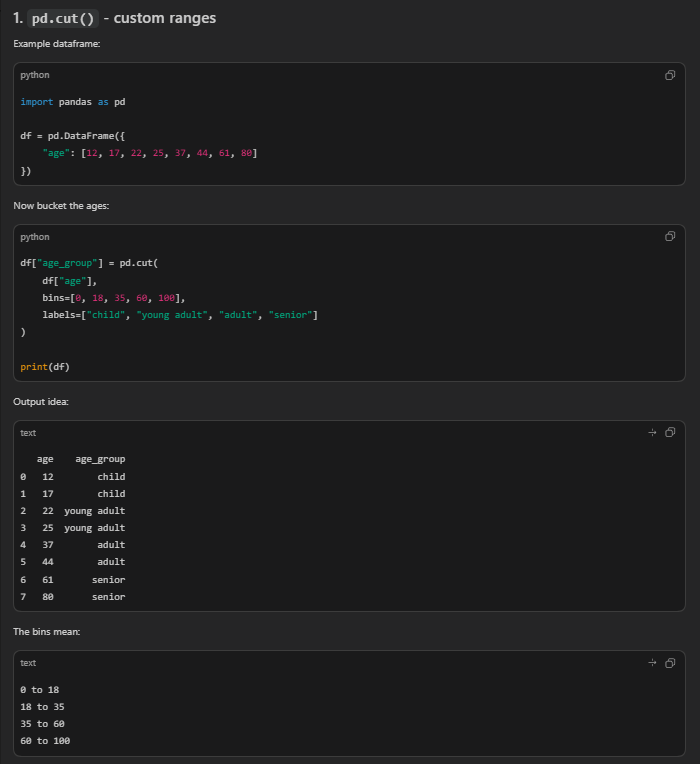

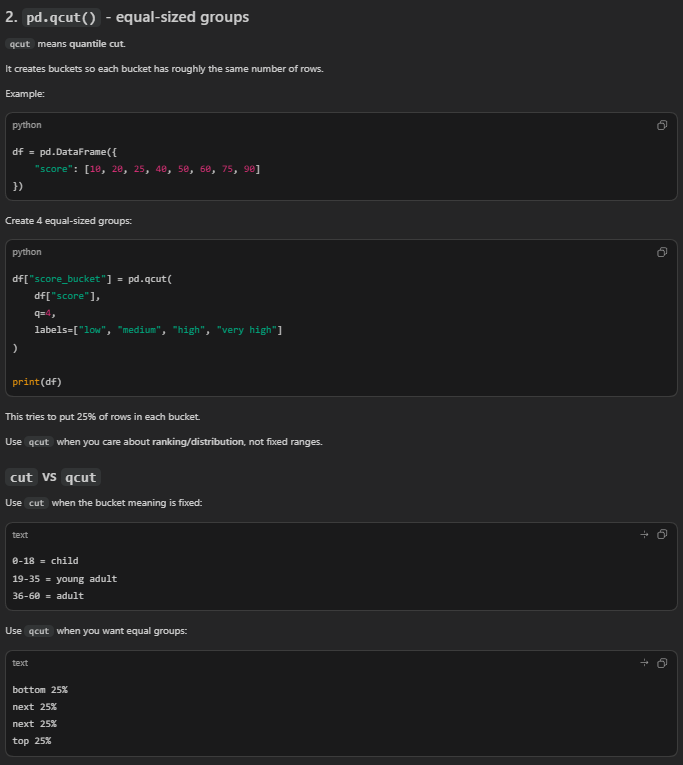